Importación de paquetes necesarios

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize
import matplotlib.pyplot as plt

Carga del dataset con los compuestos con actividad probada frente a FabI

In [3]:
ruta_input = "../data/raw/IC50_FabI.csv"
df_bruto = pd.read_csv(ruta_input, sep=';')
df_bruto.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL6034879,NaN,NaN,408.53,0.0,2.63,BDBM316893,O=C1CCc2cc(/C=C/C(=O)N3C[C@H]4CN(Cc5cccs5)C[C@...,IC50,'=',...,CHEMBL5726112,37,BindingDB Patent Bioactivity Data,NaN,2017,NaN,NaN,NaN,NaN,9130.00
1,CHEMBL568359,NaN,NaN,492.62,0.0,3.76,15e,CCCOc1c(CN(C)C(=O)/C=C/c2cnc3c(c2)CC2(CCN(C)CC...,IC50,'=',...,CHEMBL1155988,1,Scientific Literature,Bioorg Med Chem Lett,2009,NaN,NaN,NaN,NaN,26.00
2,CHEMBL3322674,NaN,NaN,349.39,0.0,2.27,AEA2,O=C1CCc2cc(/C=C/C(=O)N3CC(Oc4ccccc4)C3)cnc2N1,IC50,NaN,...,CHEMBL3352330,1,Scientific Literature,Eur J Med Chem,2014,NaN,NaN,NaN,NaN,NaN
3,CHEMBL294363,NaN,NaN,316.43,1.0,5.33,27,c1ccc(-c2ccc(Cn3cnc(-c4ccsc4)c3)cc2)cc1,IC50,'=',...,CHEMBL1133895,1,Scientific Literature,Bioorg Med Chem Lett,2001,NaN,NaN,NaN,NaN,7.66
4,CHEMBL421119,NaN,NaN,397.48,0.0,4.18,12,Nc1ccc(Cn2c3c(c4ccccc42)CCN(C(=O)c2ccc(O)cc2)C...,IC50,'=',...,CHEMBL1133924,1,Scientific Literature,Bioorg Med Chem Lett,2001,NaN,NaN,NaN,NaN,0.67


Verificación de que todas las filas examinan IC50 en S.aureus

In [4]:
organismos = df_bruto['Assay Organism'].unique()
print(f"Especies en el archivo original: {organismos}")
ensayos = df_bruto['Standard Type'].unique()
print(f"Tipos de ensayos: {ensayos}")

df_filtrado = df_bruto.dropna(subset=['Assay Organism'])
organismos = df_filtrado['Assay Organism'].unique()
print(f"Especies en el archivo filtrado: {organismos}")

Especies en el archivo original: ['Staphylococcus aureus' nan]
Tipos de ensayos: ['IC50']
Especies en el archivo filtrado: ['Staphylococcus aureus']


Filtrado del dataset para quedarnos únicamente con la información relevante de cara al entrenamiento del modelo (código smiles, standard relation y pChEMBL Value)

In [5]:
df_filtrado = df_filtrado[['Smiles','Standard Relation','pChEMBL Value']]
df_filtrado.head()

,Smiles,Standard Relation,pChEMBL Value
0,O=C1CCc2cc(/C=C/C(=O)N3C[C@H]4CN(Cc5cccs5)C[C@...,'=',5.04
1,CCCOc1c(CN(C)C(=O)/C=C/c2cnc3c(c2)CC2(CCN(C)CC...,'=',7.58
2,O=C1CCc2cc(/C=C/C(=O)N3CC(Oc4ccccc4)C3)cnc2N1,NaN,NaN
3,c1ccc(-c2ccc(Cn3cnc(-c4ccsc4)c3)cc2)cc1,'=',5.12
4,Nc1ccc(Cn2c3c(c4ccccc42)CCN(C(=O)c2ccc(O)cc2)C...,'=',6.17


Verificación de las dimensiones del df resultante e interpretación de las mismas

In [6]:
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 463 entries, 0 to 476
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Smiles             460 non-null    object 
 1   Standard Relation  417 non-null    object 
 2   pChEMBL Value      394 non-null    float64
dtypes: float64(1), object(2)
memory usage: 14.5+ KB


Podemos observar que el número de entradas pasó de 477 a 463 al eliminar las filas que no eran de S.auerus, además, no todas las variables de interés están resueltas para cada uno de los compuestos del dataframe. En este caso el cuello de botella lo marca el pChEMBL value, con 394 valores no nulos. 

Clearly we can't use all of these 463 entries for machine learning. We need a DataFrame which only contains rows where every column is non-null. To do this, we can use the Pandas function dropna with the 'how' argument set to 'any'. This means that rows which have missing values in any column are dropped. 

In [7]:
df_filtrado_dropna = df_filtrado.dropna(how='any')
print(df_filtrado_dropna.shape)

(391, 3)


After dropping null values, we are left with 391 rows.

Next, we only want to include the data for modelling if the Standard Relation is '='. We can check which Standard Relation symbols are in our DataFrame using unique to extract only the unique items in the column.

In [8]:
std_relations = df_filtrado_dropna['Standard Relation'].unique()
print(std_relations)

["'='"]


Looks like we don't need to do any cleaning there.

Standardize SMILES

In [9]:
def estandarizar_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        clean_mol = rdMolStandardize.Cleanup(mol)
        parent_clean_mol = rdMolStandardize.FragmentParent(clean_mol)
        uncharger = rdMolStandardize.Uncharger()
        uncharged_parent_clean_mol = uncharger.uncharge(parent_clean_mol)
        te = rdMolStandardize.TautomerEnumerator()
        taut_uncharged_parent_clean_mol = te.Canonicalize(uncharged_parent_clean_mol)
        return Chem.MolToSmiles(taut_uncharged_parent_clean_mol)
    except:
        return "Cannot_do"

In [10]:
df_filtrado_dropna['Smiles_Estandarizado'] = df_filtrado_dropna['Smiles'].apply(estandarizar_smiles)
df_filtrado_dropna = df_filtrado_dropna[df_filtrado_dropna['Smiles_Estandarizado'] != "Cannot_do"].copy()

[10:51:08] Initializing MetalDisconnector
[10:51:08] Running MetalDisconnector
[10:51:08] Initializing Normalizer
[10:51:08] Running Normalizer
[10:51:08] Initializing MetalDisconnector
[10:51:08] Running MetalDisconnector
[10:51:08] Initializing Normalizer
[10:51:08] Running Normalizer
[10:51:08] Running LargestFragmentChooser
[10:51:08] Running Uncharger
[10:51:08] Initializing MetalDisconnector
[10:51:08] Running MetalDisconnector
[10:51:08] Initializing Normalizer
[10:51:08] Running Normalizer
[10:51:08] Initializing MetalDisconnector
[10:51:08] Running MetalDisconnector
[10:51:08] Initializing Normalizer
[10:51:08] Running Normalizer
[10:51:08] Running LargestFragmentChooser
[10:51:08] Running Uncharger
[10:51:08] Initializing MetalDisconnector
[10:51:08] Running MetalDisconnector
[10:51:08] Initializing Normalizer
[10:51:08] Running Normalizer
[10:51:08] Initializing MetalDisconnector
[10:51:08] Running MetalDisconnector
[10:51:08] Initializing Normalizer
[10:51:08] Running Norma

Ahora se audita la estandarizacion

In [11]:
unicos_originales = df_filtrado_dropna['Smiles'].nunique()
unicos_estandarizados = df_filtrado_dropna['Smiles_Estandarizado'].nunique()
print(f"SMILES únicos originales: {unicos_originales}")
print(f"SMILES únicos tras estandarizar: {unicos_estandarizados}")
print(f"Diferencia (Duplicados ocultos revelados): {unicos_originales - unicos_estandarizados}\n")
cambios = df_filtrado_dropna[df_filtrado_dropna['Smiles'] != df_filtrado_dropna['Smiles_Estandarizado']]
print(f"Número total de filas que han sido modificadas estructuralmente: {len(cambios)}\n")

SMILES únicos originales: 344
SMILES únicos tras estandarizar: 344
Diferencia (Duplicados ocultos revelados): 0

Número total de filas que han sido modificadas estructuralmente: 216



The final important thing we need to deal with is duplicate values. To find how many duplicates we have per compound, we can use the Pandas groupby function
to group the DataFrame in terms of the 'Smiles' column,size to count the number of entries, then finally sort_values in descending order.

In [12]:
df_filtrado_dropna.groupby(['Smiles_Estandarizado']).size().sort_values(ascending=False)

Smiles_Estandarizado
Oc1cc(Cl)ccc1Oc1ccc(Cl)cc1Cl                                                 5
Cc1c(CN(C)C(=O)C=Cc2cnc3c(c2)CCC(=O)N3)oc2ccccc12                            4
CCc1cc(O)c(Oc2ccc(C(N)=O)cc2F)cc1F                                           3
NC(=O)C1Cc2cc(=CCC(=O)N3CCC(COc4ccc(F)cc4)CC3)cnc2=NC1=O                     3
O=C1CCc2cc(=CCC(=O)N3CC(OCc4ccccc4)C3)cnc2=N1                                3
                                                                            ..
CC(C)CCCC/C=C\CCCCCCCC(=O)O                                                  1
O=c1cc(/C=C/c2ccoc2)occ1Oc1ccc(Cl)cc1Cl                                      1
CC1=CC2CN(C(=O)C=Cc3cnc4c(c3)CCC(=O)N4)CC2C1                                 1
CC1CC(=O)c2c(cc3c(-c4c(O)cc(O)c5c(O)c6c(cc45)OC(C)CC6=O)c(O)cc(O)c3c2O)O1    1
O=c1cc(/C=C/c2ccoc2)occ1Oc1cccc(Cl)c1Cl                                      1
Length: 344, dtype: int64

Algunos compuestos están repetidos, uno incluso tiene 5 valores distintos. Notice that the length of the output is 344, meaning that there are 344 unique SMILES structures in the dataset. Para lidiar con esta problemática podemos hacer la media de los distintos valores asociados a cada compuesto.

In [13]:
df_filtrado_cleaned = df_filtrado_dropna.groupby(['Smiles_Estandarizado','Standard Relation'])['pChEMBL Value'].mean()
df_filtrado_cleaned = pd.DataFrame(df_filtrado_cleaned)
df_filtrado_cleaned = df_filtrado_cleaned.reset_index()
df_filtrado_cleaned.rename(columns={'Smiles_Estandarizado': 'Smiles'}, inplace=True)
df_filtrado_cleaned.head()


,Smiles,Standard Relation,pChEMBL Value
0,C#CN1C[C@@H]2CN(C(=O)C=Cc3cnc4c(c3)CCC(=O)N4)C...,'=',5.10
1,C=C(C)COC1CN(C(=O)C=Cc2cnc3c(c2)CCC(=O)N3)C1,'=',6.77
2,C=CC(C)(C)C12CC(=O)C(=O)N3C(=Cc4c[nH]cn4)C(=O)...,'=',4.40
3,CC(=O)Nc1ccc(C=CC(=O)N(C)Cc2cc3ccccc3n2C)cn1,'=',6.52
4,CC(=O)Nc1ccc(C=CC(=O)N2CC(OCc3ccncc3)C2)cn1,'=',6.58


In [14]:
smiles_a_buscar = "Cc1c(CN(C)C(=O)C=Cc2cnc3c(c2)CCC(=O)N3)oc2ccccc12"
resultado = df_filtrado_cleaned[df_filtrado_cleaned['Smiles'] == smiles_a_buscar]
print(f"Valor pChEMBL: {resultado['pChEMBL Value'].values[0]}")

Valor pChEMBL: 6.945


Aunque hacer la media directamente es la solución más rápida, es mucho más recomendable descartar los valores atípicos (outliers) antes de calcular la media para evitar que errores experimentales distorsionen tu variable objetivo. Para eso he creado una función
que permite eliminar los valores outliers y quedarnos solamente con la media de valores típicos.

In [15]:
def filtrar_outliers_y_promediar(grupo):
    if len(grupo) >= 3:
        Q1 = grupo.quantile(0.25)
        Q3 = grupo.quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        grupo_filtrado = grupo[(grupo >= limite_inferior) & (grupo <= limite_superior)]
        if grupo_filtrado.empty:
            return grupo.median()
        return grupo_filtrado.mean()
    else:
        return grupo.mean()
     

In [16]:
df_filtrado_cleaned = df_filtrado_dropna.groupby(['Smiles_Estandarizado', 'Standard Relation'])['pChEMBL Value'].apply(filtrar_outliers_y_promediar)
df_filtrado_cleaned = pd.DataFrame(df_filtrado_cleaned)
df_filtrado_cleaned = df_filtrado_cleaned.reset_index()
df_filtrado_cleaned.rename(columns={'Smiles_Estandarizado': 'Smiles'}, inplace=True)
df_filtrado_cleaned.head()

,Smiles,Standard Relation,pChEMBL Value
0,C#CN1C[C@@H]2CN(C(=O)C=Cc3cnc4c(c3)CCC(=O)N4)C...,'=',5.10
1,C=C(C)COC1CN(C(=O)C=Cc2cnc3c(c2)CCC(=O)N3)C1,'=',6.77
2,C=CC(C)(C)C12CC(=O)C(=O)N3C(=Cc4c[nH]cn4)C(=O)...,'=',4.40
3,CC(=O)Nc1ccc(C=CC(=O)N(C)Cc2cc3ccccc3n2C)cn1,'=',6.52
4,CC(=O)Nc1ccc(C=CC(=O)N2CC(OCc3ccncc3)C2)cn1,'=',6.58


In [17]:
smiles_a_buscar = "Cc1c(CN(C)C(=O)C=Cc2cnc3c(c2)CCC(=O)N3)oc2ccccc12"
resultado = df_filtrado_cleaned[df_filtrado_cleaned['Smiles'] == smiles_a_buscar]
print(f"Valor pChEMBL: {resultado['pChEMBL Value'].values[0]}")

Valor pChEMBL: 7.586666666666667


Let's see what the distribution of pChEMBL values looks like. We can achieve this using the violinplot function in Seaborn. We just need to pass the DataFrame column to the function like so:

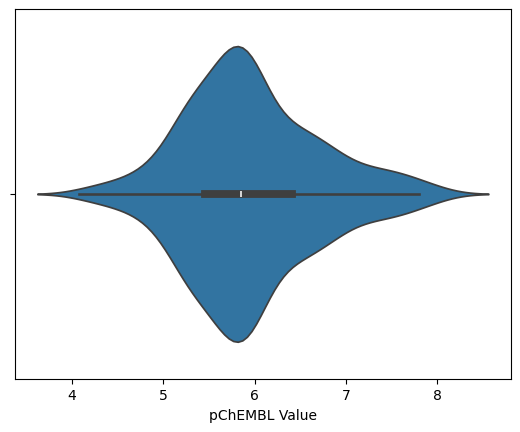

In [18]:
sns.violinplot(x=df_filtrado_cleaned['pChEMBL Value'])
plt.savefig("../results/distribucion_pchembl_violin.png", dpi=300, bbox_inches="tight")
plt.show()


In [19]:
df_filtrado_cleaned['pChEMBL Value'].describe()

count    344.000000
mean       5.954769
std        0.740217
min        4.080000
25%        5.460000
50%        5.855000
75%        6.405000
max        8.100000
Name: pChEMBL Value, dtype: float64

Se define la ruta de salida del output del script para utilizarlo como input del siguiente.

In [20]:
ruta_salida = '../data/processed/chembl_curado.csv'
df_filtrado_cleaned.to_csv(ruta_salida, index=False)